Mean of weights_sum (weights_sum > 0): 285.59603051075715
Median of weights_sum (weights_sum > 0): 47.0


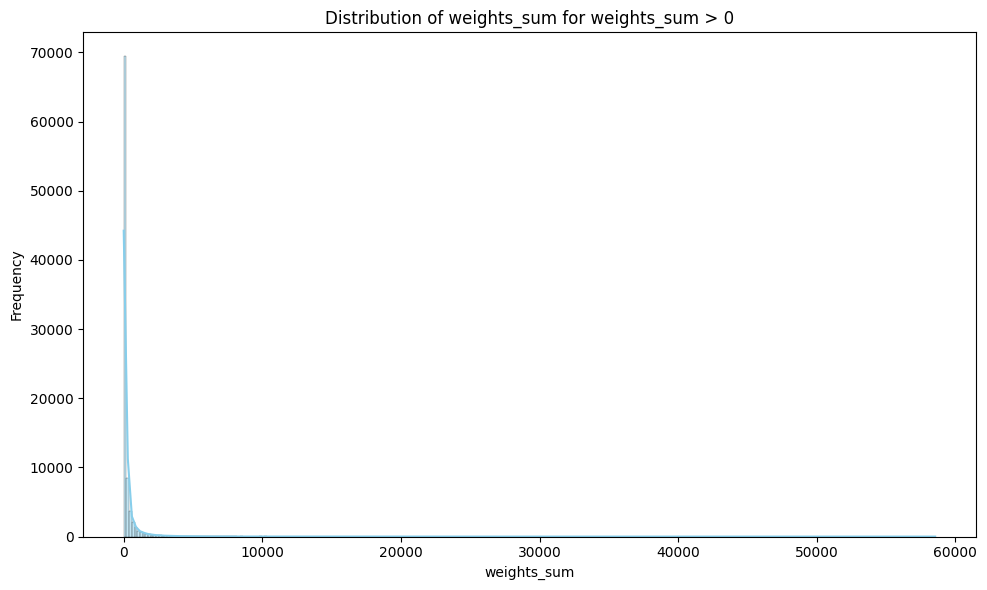

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File path to the CSV file
file_path = "../dataset/perfume_dataset.csv"  # Adjust path as needed

# Read the CSV file
df = pd.read_csv(file_path, dtype={'weights_sum': float})

# Filter rows with weights_sum > 0
df_positive = df[df['weights_sum'] > 0]

# Calculate mean and median of weights_sum
mean_val = df_positive['weights_sum'].mean()
median_val = df_positive['weights_sum'].median()

print("Mean of weights_sum (weights_sum > 0):", mean_val)
print("Median of weights_sum (weights_sum > 0):", median_val)

# Plot the distribution of weights_sum
plt.figure(figsize=(10, 6))
sns.histplot(df_positive['weights_sum'], bins=300, kde=True, color='skyblue')
plt.xlabel("weights_sum")
plt.ylabel("Frequency")
plt.title("Distribution of weights_sum for weights_sum > 0")
plt.tight_layout()
plt.show()


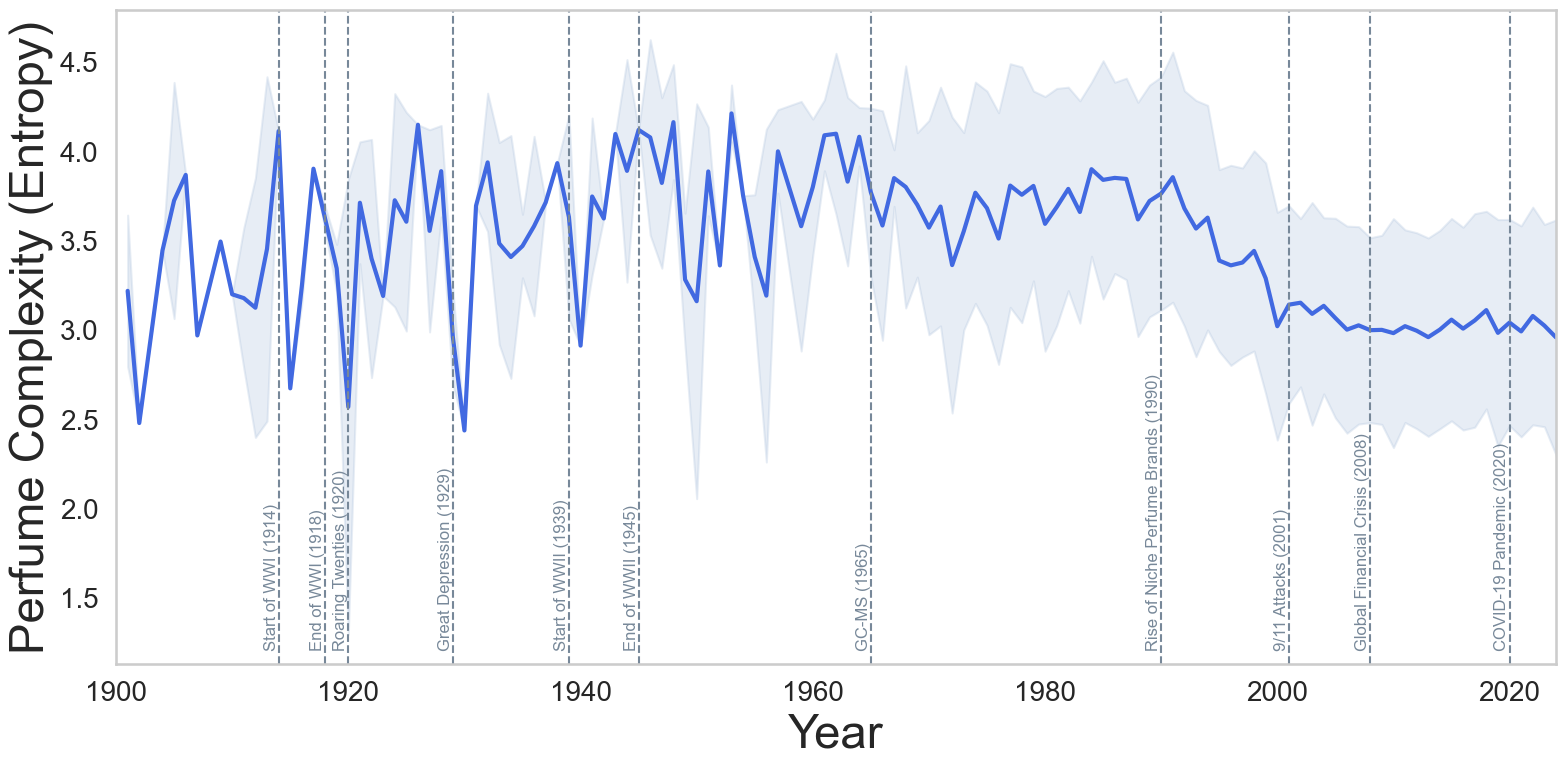

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from math import log2
import ast
import numpy as np
from collections import defaultdict
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")  # Seaborn theme for nicer plots

def parse_notes(notes_str):
    """
    Parses the 'notes' column and returns a dictionary of {note_name: fraction}.
    
    The fraction is defined as note_weight / (sum of all positive note_weight).
    Notes with non-positive weights (<= 0) are ignored.
    If the total of valid weights is 0 or parsing fails, returns an empty dict.
    """
    try:
        # Replace CSV-style doubled quotes
        notes_str = notes_str.replace('""', '"')
        
        # Convert the string to a Python object (list of dicts)
        notes_list = ast.literal_eval(notes_str)
        
        # 1. Gather total of all positive weights
        total_weight = 0
        for item in notes_list:
            for note, data in item.items():
                w = data.get('weight', 0)
                if w > 0:  # skip negatives or zero
                    total_weight += w

        # If total_weight is zero or negative, return empty
        if total_weight <= 0:
            return {}

        # 2. Build dict of {note: fraction}
        note_fractions = {}
        for item in notes_list:
            for note, data in item.items():
                w = data.get('weight', 0)
                if w > 0:
                    fraction = w / total_weight
                    note_fractions[note] = fraction
        
        return note_fractions
    
    except (ValueError, SyntaxError):
        # If parsing fails, return empty
        return {}

def calculate_shannon_entropy(weight_dict):
    """
    Calculates the Shannon entropy given a dictionary of note fractions.
    
    Since the input values are fractions (p_i), this computes:
      H = -sum(p_i * log2(p_i))
    """
    total = sum(weight_dict.values())
    if total == 0:
        return 0
    entropy = 0
    for weight_fraction in weight_dict.values():
        p = weight_fraction
        if p > 0:
            entropy -= p * log2(p)
    return entropy

def main():
    csv_file = "../dataset/perfume_dataset.csv"

    # Read the CSV file
    try:
        df = pd.read_csv(csv_file, dtype={'year': float, 'notes': str, 'weights_sum': float})
    except FileNotFoundError:
        print(f"The file '{csv_file}' was not found.")
        return
    except pd.errors.EmptyDataError:
        print("No data found in the CSV file.")
        return
    except Exception as e:
        print(f"An error occurred while reading the CSV file: {e}")
        return

    # Drop rows with missing 'year', 'notes', or 'weights_sum'
    df = df.dropna(subset=['year', 'notes', 'weights_sum'])
    df['weights_sum'] = pd.to_numeric(df['weights_sum'], errors='coerce')
    df = df.dropna(subset=['weights_sum'])

    # only calculte the perfumes above the Mean of weights_sum
    df_filtered = df[df['weights_sum'] >= 286]

    if df_filtered.empty:
        print("No perfumes found with 'weights_sum' greater than 280.")
        return

    # Further filter years between 1900 and 2024
    df_filtered = df_filtered[(df_filtered['year'] >= 1900) & (df_filtered['year'] <= 2024)]

    # Parse the 'notes' column
    df_filtered['parsed_notes'] = df_filtered['notes'].apply(parse_notes)

    # Calculate Shannon entropy for each perfume
    df_filtered['entropy'] = df_filtered['parsed_notes'].apply(calculate_shannon_entropy)

    # Group by year and calculate mean and standard deviation of entropy
    entropy_stats = df_filtered.groupby('year')['entropy'].agg(['mean', 'std']).reset_index()
    entropy_stats['std'] = entropy_stats['std'].fillna(0)
    entropy_stats = entropy_stats.sort_values('year')

    # Start plotting with Seaborn styling
    plt.figure(figsize=(16, 8))
    
    # Plot the mean Shannon entropy time series with seaborn
    sns.lineplot(data=entropy_stats, x='year', y='mean', color='royalblue', linewidth=3)
    
    # Manually add the confidence band (±1 std)
    plt.fill_between(
        entropy_stats['year'],
        entropy_stats['mean'] - entropy_stats['std'],
        entropy_stats['mean'] + entropy_stats['std'],
        color='lightsteelblue',
        alpha=0.3,
        label='±1 Standard Deviation'
    )
    
    # Use Seaborn's "viridis" palette as a substitute for a rocket-like colorbar
    # (You can adjust the range as needed)
#     ww2_years = [1939, 1945]
#     ww2_colors = [sns.color_palette("viridis", as_cmap=True)(x) for x in np.linspace(0.2, 0.3, len(ww2_years))]
#     for year, col in zip(ww2_years, ww2_colors):
#         plt.axvline(year, color=col, linestyle='--', linewidth=1.5)
#         plt.text(year - 1.2, plt.ylim()[0] + (plt.ylim()[1] - plt.ylim()[0]) * 0.02,
#                  f'WWII {year}', rotation=90, verticalalignment='bottom', color=col, fontsize=10)
    
#     # GC-MS marker
#     gc_ms_year = 1965
#     gc_ms_color = sns.color_palette("viridis", as_cmap=True)(0.5)
#     plt.axvline(gc_ms_year, color=gc_ms_color, linestyle='--', linewidth=2)
#     plt.text(gc_ms_year - 1.2, plt.ylim()[0] + (plt.ylim()[1] - plt.ylim()[0]) * 0.02,
#              'GC-MS (1965)', rotation=90, verticalalignment='bottom', color=gc_ms_color, fontsize=10)
    
#     # Pre-WWII events
#     pre_ww2_events = [
#         (1914, 'Start of WWI (1914)'),
#         (1918, 'End of WWI (1918)'),
#         (1920, 'Roaring Twenties (1920)'),
#         (1929, 'Great Depression (1929)'),
#         (1939, 'Start of WWII (1939)'),
#         (1945, 'End of WWII (1945)'),
#         (1965, 'GC-MS (1965)')

#     ]
#     pre_ww2_colors = [sns.color_palette("rocket", as_cmap=True)(x) for x in np.linspace(0.3, 0.4, len(pre_ww2_events))]
#     for (year, label), col in zip(pre_ww2_events, pre_ww2_colors):
#         plt.axvline(year, color='darkgray', linestyle='--', linewidth=1.5)
#         plt.text(year - 1.2, plt.ylim()[0] + (plt.ylim()[1] - plt.ylim()[0]) * 0.02,
#                  label, rotation=90, verticalalignment='bottom', color='darkgray', fontsize=10)
    
    # Post-WWII events
    all_events = [
        (1914, 'Start of WWI (1914)'),
        (1918, 'End of WWI (1918)'),
        (1920, 'Roaring Twenties (1920)'),
        (1929, 'Great Depression (1929)'),
        (1939, 'Start of WWII (1939)'),
        (1945, 'End of WWII (1945)'),
        (1965, 'GC-MS (1965)'),
        (1990, 'Rise of Niche Perfume Brands (1990)'),
        (2001, '9/11 Attacks (2001)'),
        (2008, 'Global Financial Crisis (2008)'),
        # (2010, 'E-commerce Boom (2010)'),
        (2020, 'COVID-19 Pandemic (2020)'),
        # (2023, 'Sustainable Perfume Movement (2023)')
    ]

    all_events_colors = [sns.color_palette("ch:s=.25,rot=-.25", as_cmap=True)(x) for x in np.linspace(0.4, 0.7, len(all_events))]
    for (year, label), col in zip(all_events, all_events_colors):
        plt.axvline(year, color='lightslategray', linestyle='--', linewidth=1.5)
        plt.text(year - 1.3, plt.ylim()[0] + (plt.ylim()[1] - plt.ylim()[0]) * 0.02,
                 label, rotation=90, verticalalignment='bottom', color='lightslategray', fontsize=12)

    # Remove event labels from legend (only main elements in legend)
    # handles, labels = plt.gca().get_legend_handles_labels()
    # plt.legend(handles, labels, loc='upper right', fontsize=12)

    # plt.title('Shannon Entropy of Perfume Notes Over Time (1900-2024)\n(Weights Sum > 280)', fontsize=18)
    plt.xlabel('Year', fontsize=34)
    plt.ylabel('Perfume Complexity (Entropy)', fontsize=34)
    plt.xlim(1900, 2024)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig("../output/Figure_2a.svg", format="svg", dpi=300)


    plt.show()

    # Optional: Display summary statistics
    overall_mean = df_filtered['entropy'].mean()
    overall_median = df_filtered['entropy'].median()
    # print(f"Overall Mean Shannon Entropy (weights_sum > 280): {overall_mean:.2f}")
    # print(f"Overall Median Shannon Entropy (weights_sum > 280): {overall_median:.2f}")

if __name__ == "__main__":
    main()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from math import log2
import ast
from collections import defaultdict

def parse_notes(notes_str):
    """
    Parses the 'notes' column to extract 'weight_tenet' for each note.
    Returns a dictionary with {note_name: weight_tenet_value}.
    """
    try:
        # Replace the CSV-style double double-quotes
        notes_str = notes_str.replace('""', '"')
        # Safely parse the string (which should now look like valid Python literal)
        notes_list = ast.literal_eval(notes_str)
        
        weights = {}
        for item in notes_list:
            for note, data in item.items():
                weights[note] = data.get('weight_tenet', 0)
        return weights
    except (ValueError, SyntaxError):
        return {}

def to_probability_dist(weight_dict, epsilon=1e-9):
    """
    Convert a {note: weight} dict into a probability distribution {note: p_i}.
    Small epsilon ensures we never get zero exactly, which helps with divergence computations.
    """
    total = sum(weight_dict.values())
    if total <= 0:
        # If total is 0 or negative, return an empty dict
        return {}
    # Add epsilon to each note, then re-normalize below
    prob = {note: (wt / total) for note, wt in weight_dict.items()}
    return prob

def build_historical_distribution(rows):
    """
    Given a list of rows (each row has a 'parsed_notes' dict),
    accumulate total weights for each note, then turn it into a probability distribution.
    """
    combined = defaultdict(float)
    for row in rows:
        for note, wt in row['parsed_notes'].items():
            combined[note] += wt

    # Convert to probability distribution
    prob_dist = to_probability_dist(combined)
    return prob_dist

def kl_divergence(p_dist, q_dist, epsilon=1e-9):
    """
    KL Divergence KL(P || Q) = sum( p_i * log2(p_i / q_i) ), with q_i >= epsilon.
    This is used as a helper inside the Jensen-Shannon divergence function.
    """
    kl = 0.0
    for note, p_i in p_dist.items():
        if p_i > 0:  # skip zero-prob terms
            q_i = q_dist.get(note, 0)
            if q_i < epsilon:
                q_i = epsilon
            kl += p_i * log2(p_i / q_i)
    return kl

def js_divergence(p_dist, q_dist, epsilon=1e-9):
    """
    Computes the Jensen-Shannon Divergence between p_dist and q_dist:
      JSD(P || Q) = 0.5 * KL(P || M) + 0.5 * KL(Q || M),
    where M = 0.5*(P + Q). This is symmetric and bounded between 0 and 1 in base 2.

    Assumes p_dist and q_dist sum to ~1 each (they are probability distributions).
    """
    # Build the "midpoint" distribution M
    all_notes = set(p_dist.keys()) | set(q_dist.keys())
    M = {}
    for note in all_notes:
        p_val = p_dist.get(note, 0.0)
        q_val = q_dist.get(note, 0.0)
        M[note] = 0.5 * p_val + 0.5 * q_val

    # Compute KL(P || M) and KL(Q || M), then average
    kl_pm = kl_divergence(p_dist, M, epsilon=epsilon)
    kl_qm = kl_divergence(q_dist, M, epsilon=epsilon)
    jsd = 0.5 * kl_pm + 0.5 * kl_qm

    return jsd

def main():
    csv_file = "../dataset/perfume_dataset.csv"

    # 1) Read CSV and drop missing
    try:
        df = pd.read_csv(csv_file, dtype={'year': float, 'notes': str, 'weights_sum': float})
    except FileNotFoundError:
        print(f"The file '{csv_file}' was not found.")
        return
    except pd.errors.EmptyDataError:
        print("No data found in the CSV file.")
        return
    except Exception as e:
        print(f"An error occurred while reading the CSV file: {e}")
        return

    df = df.dropna(subset=['year', 'notes', 'weights_sum'])
    df['weights_sum'] = pd.to_numeric(df['weights_sum'], errors='coerce')
    df = df.dropna(subset=['weights_sum'])

    # Filter: weights_sum > 100 (you can change this threshold)
    df_filtered = df[df['weights_sum'] >= 2860]
    if df_filtered.empty:
        print("No perfumes found with 'weights_sum' > 100.")
        return

    # Further filter: 1900 <= year <= 2024
    df_filtered = df_filtered[(df_filtered['year'] >= 1900) & (df_filtered['year'] <= 2024)]
    if df_filtered.empty:
        print("No perfumes left after filtering by year.")
        return

    # 2) Parse notes
    df_filtered['parsed_notes'] = df_filtered['notes'].apply(parse_notes)

    # 3) Sort by year, then by index
    df_filtered = df_filtered.sort_values('year', ascending=True)
    df_filtered = df_filtered.sort_index(ascending=True)

    # 4) For each row (perfume), compare with the distribution of all past rows
    innovation_scores = []
    past_rows = []  # will accumulate rows from all previous years

    for idx, row in df_filtered.iterrows():
        # If no past data, define "innovation" as 0
        if not past_rows:
            innovation_scores.append(0.0)
        else:
            # Build historical distribution from all previous rows
            Q = build_historical_distribution(past_rows)
            # P = distribution for this perfume
            P = to_probability_dist(row['parsed_notes'])

            # If no notes in the current perfume, define 0
            if not P:
                innovation_scores.append(0.0)
            else:
                # Use Jensen-Shannon Divergence
                js_value = js_divergence(P, Q)
                innovation_scores.append(js_value)

        # Add current perfume to the "past" set
        past_rows.append(row)
        
    df_filtered['innovation_score'] = innovation_scores

    # 5) Group by year => see which years had the most "innovative" perfumes on average
    innovation_stats = df_filtered.groupby('year')['innovation_score'].agg(['mean', 'std']).reset_index()
    innovation_stats['std'] = innovation_stats['std'].fillna(0)
    innovation_stats = innovation_stats.sort_values('year')

    # Start plotting with Seaborn styling
    plt.figure(figsize=(16, 8))
    
    # Plot the mean Shannon entropy time series with seaborn
    sns.lineplot(data=innovation_stats, x='year', y='mean', color='indianred', linewidth=3)
    
    # Manually add the confidence band (±1 std)
    plt.fill_between(
        innovation_stats['year'],
        innovation_stats['mean'] - innovation_stats['std'],
        innovation_stats['mean'] + innovation_stats['std'],
        color='tomato',
        alpha=0.15,
        label='±1 Standard Deviation'
    )
    
    # Use Seaborn's "viridis" palette as a substitute for a rocket-like colorbar
    # (You can adjust the range as needed)
#     ww2_years = [1939, 1945]
#     ww2_colors = [sns.color_palette("viridis", as_cmap=True)(x) for x in np.linspace(0.2, 0.3, len(ww2_years))]
#     for year, col in zip(ww2_years, ww2_colors):
#         plt.axvline(year, color=col, linestyle='--', linewidth=1.5)
#         plt.text(year - 1.2, plt.ylim()[0] + (plt.ylim()[1] - plt.ylim()[0]) * 0.02,
#                  f'WWII {year}', rotation=90, verticalalignment='bottom', color=col, fontsize=10)
    
#     # GC-MS marker
#     gc_ms_year = 1965
#     gc_ms_color = sns.color_palette("viridis", as_cmap=True)(0.5)
#     plt.axvline(gc_ms_year, color=gc_ms_color, linestyle='--', linewidth=2)
#     plt.text(gc_ms_year - 1.2, plt.ylim()[0] + (plt.ylim()[1] - plt.ylim()[0]) * 0.02,
#              'GC-MS (1965)', rotation=90, verticalalignment='bottom', color=gc_ms_color, fontsize=10)
    
#     # Pre-WWII events
#     pre_ww2_events = [
#         (1914, 'Start of WWI (1914)'),
#         (1918, 'End of WWI (1918)'),
#         (1920, 'Roaring Twenties (1920)'),
#         (1929, 'Great Depression (1929)'),
#         (1939, 'Start of WWII (1939)'),
#         (1945, 'End of WWII (1945)'),
#         (1965, 'GC-MS (1965)')

#     ]
#     pre_ww2_colors = [sns.color_palette("rocket", as_cmap=True)(x) for x in np.linspace(0.3, 0.4, len(pre_ww2_events))]
#     for (year, label), col in zip(pre_ww2_events, pre_ww2_colors):
#         plt.axvline(year, color='darkgray', linestyle='--', linewidth=1.5)
#         plt.text(year - 1.2, plt.ylim()[0] + (plt.ylim()[1] - plt.ylim()[0]) * 0.02,
#                  label, rotation=90, verticalalignment='bottom', color='darkgray', fontsize=10)
    
    # Post-WWII events
    all_events = [
        (1914, 'Start of WWI (1914)'),
        (1918, 'End of WWI (1918)'),
        (1920, 'Roaring Twenties (1920)'),
        (1929, 'Great Depression (1929)'),
        (1939, 'Start of WWII (1939)'),
        (1945, 'End of WWII (1945)'),
        (1965, 'GC-MS (1965)'),
        (1990, 'Rise of Niche Perfume Brands (1990)'),
        (2001, '9/11 Attacks (2001)'),
        (2008, 'Global Financial Crisis (2008)'),
        # (2010, 'E-commerce Boom (2010)'),
        (2020, 'COVID-19 Pandemic (2020)'),
        # (2023, 'Sustainable Perfume Movement (2023)')
    ]

    all_events_colors = [sns.color_palette("ch:s=.25,rot=-.25", as_cmap=True)(x) for x in np.linspace(0.4, 0.7, len(all_events))]
    for (year, label), col in zip(all_events, all_events_colors):
        plt.axvline(year, color='lightslategray', linestyle='--', linewidth=1.5)
        plt.text(year - 1.3, plt.ylim()[0] - 0.32,
                 label, rotation=90, verticalalignment='bottom', color='lightslategray', fontsize=12)

    # Remove event labels from legend (only main elements in legend)
    # handles, labels = plt.gca().get_legend_handles_labels()
    # plt.legend(handles, labels, loc='upper right', fontsize=12)

    # plt.title('Shannon Entropy of Perfume Notes Over Time (1900-2024)\n(Weights Sum > 280)', fontsize=18)
    plt.xlabel('Year', fontsize=34)
    plt.ylabel('Perfume Innovation (JSD)', fontsize=34)
    plt.xlim(1900, 2024)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.ylim(0.01,1)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig("../output/Figure_2b.svg", format="svg", dpi=300)

    plt.show()

    # Optional: Display summary statistics
    # overall_mean = df_filtered['entropy'].mean()
    # overall_median = df_filtered['entropy'].median()
    # print(f"Overall Mean Shannon Entropy (weights_sum > 280): {overall_mean:.2f}")
    # print(f"Overall Median Shannon Entropy (weights_sum > 280): {overall_median:.2f}")

if __name__ == "__main__":
    main()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import numpy as np
import seaborn as sns

# ------------------------------------------------------------------
# 1) Load the CSV file
# ------------------------------------------------------------------
file_path = "../dataset/perfume_dataset.csv"  # Adjust if needed
data = pd.read_csv(file_path, encoding='latin1', sep=',', on_bad_lines='skip')

# ------------------------------------------------------------------
# Fill missing 'Type' with 'Designer perfumery', then split by '|'
# ------------------------------------------------------------------
data['Type'] = data['Type'].fillna('')
data.loc[data['Type'].str.strip() == '', 'Type'] = 'Designer perfumery'
data = data.assign(Type=data['Type'].str.split('|')).explode('Type')
data['Type'] = data['Type'].str.strip()  # remove extra spaces

# ------------------------------------------------------------------
# 2) Define a helper function to calculate weighted average ratings
# ------------------------------------------------------------------
def calculate_weighted_average(df, column, max_scale=5):
    """
    Parses each cell in `df[column]` as a JSON/dict of {rating_value: count},
    then computes a weighted average rating. The result is stored in
    df[f'average_{column}'].
    """
    # Ensure each cell is a dict
    df[column] = df[column].apply(
        lambda x: x if isinstance(x, dict) else json.loads(x) if pd.notna(x) else {}
    )
    
    def get_weighted_avg(d):
        if not d or sum(d.values()) == 0:
            return np.nan
        numeric_keys = sorted(int(k) for k in d.keys())
        actual_max = numeric_keys[-1]
        # Scale factor for normalizing to 1..5
        scale_factor = max_scale / actual_max
        total_weighted = sum((int(k) * scale_factor) * v for k, v in d.items())
        total_counts = sum(d.values())
        return total_weighted / total_counts
    
    df[f'average_{column}'] = df[column].apply(get_weighted_avg)

# ------------------------------------------------------------------
# 3) Calculate weighted averages for these columns
# ------------------------------------------------------------------
for column in ['price_rating', 'sillage_rating', 'rating', 'longevity_rating']:
    calculate_weighted_average(data, column)

# ------------------------------------------------------------------
# 4) Drop rows that are missing any of these new average rating columns
# ------------------------------------------------------------------
data.dropna(
    subset=[
        'average_price_rating',
        'average_sillage_rating',
        'average_rating',
        'average_longevity_rating'
    ],
    inplace=True
)

# ------------------------------------------------------------------
# 5) (Optional) Filter rows by weights_sum if needed
# ------------------------------------------------------------------
# data = data[data['weights_sum'] > 280]

# ------------------------------------------------------------------
# HELPER: Return DataFrames of mean & std by (year, Type)
# ------------------------------------------------------------------
def mean_std_rating_by_type(df, rating_col):
    """
    Groups by (year, Type) -> computes mean & std.
    Returns two DataFrames pivoted so that each Type is a column:
       pivoted_mean[Type], pivoted_std[Type].
    Also adds columns for 'Total_mean'/'Total_std' (the all-Type aggregates).
    """
    grouped = df.groupby(['year','Type'])[rating_col].agg(['mean','std']).reset_index()
    pivoted_mean = grouped.pivot(index='year', columns='Type', values='mean')
    pivoted_std  = grouped.pivot(index='year', columns='Type', values='std')
    
    # Compute overall stats for all Types in that year
    total_stats = df.groupby('year')[rating_col].agg(['mean','std']).rename(
        columns={'mean': 'Total_mean', 'std': 'Total_std'}
    )
    # Join 'Total_mean'/'Total_std' as columns
    pivoted_mean = pivoted_mean.join(total_stats['Total_mean'], on='year')
    pivoted_std  = pivoted_std.join(total_stats['Total_std'], on='year')
    
    return pivoted_mean, pivoted_std

# We’ll make a list of (column, human_readable_label) for plotting
ratings_info = [
    ('average_longevity_rating', 'Longevity'),
    ('average_sillage_rating',   'Sillage'),
    ('average_price_rating',     'Price'),
    ('average_rating',           'Rating'),
]

# -------------------------------------------------
# SEABORN STYLE (optional – can remove or adjust)
# -------------------------------------------------
sns.set_style("white")

# -------------------------------------------------
# CREATE THE FIGURE
# -------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Example color choices for each type (optional)
colors = {
    "Niche designer": "#1f77b4",      # blue
    "Designer perfumery": "#8c564b"  # brown
}

# -------------------------------------------------
# LOOP THROUGH EACH RATING TYPE & PLOT
# -------------------------------------------------
for i, (ax, (rating_col, rating_label)) in enumerate(zip(axes.flat, ratings_info)):
    # 1) Compute mean & std by (year, Type)
    pivoted_mean, pivoted_std = mean_std_rating_by_type(data, rating_col)
    
    # 2) Create 5-year rolling versions
    #    (this uses the "year" as a numeric index, so it needs to be sorted)
    pivoted_mean = pivoted_mean.sort_index()
    pivoted_std  = pivoted_std.sort_index()
    
    # Rolling(5) => 5-year window; min_periods=1 ensures we get a value even if fewer than 5
    pivoted_mean_5yr = pivoted_mean.rolling(window=5, min_periods=1).mean()
    pivoted_std_5yr  = pivoted_std.rolling(window=5, min_periods=1).mean()

    # 3) Plot lines for each category
    lines_to_plot = ["Niche designer", "Designer perfumery"]
    for cat in lines_to_plot:
        if cat in pivoted_mean_5yr.columns:
            ax.plot(
                pivoted_mean_5yr.index,
                pivoted_mean_5yr[cat],
                label=cat,
                linestyle='-',
                alpha=0.9,
                color=colors.get(cat, None)
            )
            # Plot ±1 std band using the rolling std
            if cat in pivoted_std_5yr.columns:
                lower = pivoted_mean_5yr[cat] - pivoted_std_5yr[cat]
                upper = pivoted_mean_5yr[cat] + pivoted_std_5yr[cat]
                ax.fill_between(
                    pivoted_mean_5yr.index,
                    lower, 
                    upper,
                    alpha=0.2,
                    color=colors.get(cat, None)
                )

    # 4) Axis labeling & styling
    if i == 3:
        # Only show legend on last subplot
        ax.legend(frameon=False, fontsize=18)
    else:
        # If automatically created a legend, remove it here
        pass

    # Adjust axis labels
    if i == 0:
        ax.set_xlabel(None)
        ax.set_ylabel("Mean Longevity", fontsize=28)
    elif i == 1:
        ax.set_xlabel(None)
        ax.set_ylabel("Mean Sillage", fontsize=28)
    elif i == 2:
        ax.set_xlabel("Year", fontsize=28)
        ax.set_ylabel("Mean Price", fontsize=28)
    elif i == 3:
        ax.set_xlabel("Year", fontsize=28)
        ax.set_ylabel("Mean Rating", fontsize=28)

    # Set reasonable x-limits and y-limits
    ax.set_xlim(1900, 2024)
    ax.set_ylim(1.1, 5)

    # Remove the grid
    ax.grid(False)
    
    # Increase tick label size
    ax.tick_params(labelsize=16)  # affects both x & y

# -------------------------------------------------
# FINALIZE & SAVE
# -------------------------------------------------
plt.tight_layout()
plt.savefig("../output/Figure_2d.svg", format="svg", dpi=300)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import numpy as np
from collections import defaultdict
from math import log2

sns.set_theme(style="ticks", context="talk")


########################################
# A) Perfume Complexity (Shannon Entropy)
########################################

def parse_notes_for_entropy(notes_str):
    try:
        notes_str = notes_str.replace('""', '"')
        notes_list = ast.literal_eval(notes_str)
        total_weight = sum(
            data.get('weight', 0)
            for item in notes_list
            for data in item.values()
            if data.get('weight', 0) > 0
        )
        if total_weight <= 0:
            return {}
        return {
            note: data['weight'] / total_weight
            for item in notes_list
            for note, data in item.items()
            if data.get('weight', 0) > 0
        }
    except (ValueError, SyntaxError):
        return {}


def calculate_shannon_entropy(weight_dict):
    """
    Calculates the Shannon entropy given a dictionary of note fractions.
    
    Since the input values are fractions (p_i), this computes:
      H = -sum(p_i * log2(p_i))
    """
    total = sum(weight_dict.values())
    if total == 0:
        return 0
    entropy = 0
    for weight_fraction in weight_dict.values():
        p = weight_fraction
        if p > 0:
            entropy -= p * log2(p)
    return entropy

########################################
# B) Perfume Innovation (Jensen–Shannon Divergence)
########################################

def parse_notes_for_innovation(notes_str):
    try:
        notes_str = notes_str.replace('""', '"')
        notes_list = ast.literal_eval(notes_str)
        return {note: data.get('weight_tenet', 0) for item in notes_list for note, data in item.items()}
    except (ValueError, SyntaxError):
        return {}

def to_probability_dist(weight_dict):
    total = sum(weight_dict.values())
    return {note: wt / total for note, wt in weight_dict.items()} if total > 0 else {}

def build_historical_distribution(rows):
    combined = defaultdict(float)
    for row in rows:
        for note, wt in row['parsed_notes_innovation'].items():
            combined[note] += wt
    return to_probability_dist(combined)

def kl_divergence(p_dist, q_dist, epsilon=1e-9):
    return sum(
        p_i * log2(p_i / max(q_dist.get(note, 0.0), epsilon))
        for note, p_i in p_dist.items() if p_i > 0
    )

def js_divergence(p_dist, q_dist):
    all_notes = set(p_dist) | set(q_dist)
    M = {note: 0.5 * (p_dist.get(note, 0.0) + q_dist.get(note, 0.0)) for note in all_notes}
    return 0.5 * kl_divergence(p_dist, M) + 0.5 * kl_divergence(q_dist, M)


########################################
# C) Parse Rating Dictionary
########################################

def parse_average_rating(rating_str):
    try:
        rating_str = rating_str.replace('""', '"')
        rating_dict = ast.literal_eval(rating_str)
        total_votes = sum(float(v) for v in rating_dict.values())
        weighted_sum = sum(float(k) * float(v) for k, v in rating_dict.items())
        return weighted_sum / total_votes if total_votes > 0 else 0.0
    except:
        return 0.0


########################################
# D) Main Processing & Plotting
########################################

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# def get_pareto_front(df, maximize_complexity=True, minimize_innovation=True):
#     """
#     Returns the indices of the Pareto front.
#     - maximize_complexity: if True, prefers higher complexity.
#     - minimize_innovation: if True, prefers lower innovation.
#     """
#     data = df[['Perfume_Complexity', 'Perfume_Innovation']].values
#     pareto_idx = []
#     for i, (c1, i1) in enumerate(data):
#         dominated = False
#         for j, (c2, i2) in enumerate(data):
#             if i == j:
#                 continue
#             better_c = c2 >= c1 if maximize_complexity else c2 <= c1
#             better_i = i2 <= i1 if minimize_innovation else i2 >= i1
#             strictly_better = (c2 > c1 if maximize_complexity else c2 < c1) or \
#                               (i2 < i1 if minimize_innovation else i2 > i1)
#             if better_c and better_i and strictly_better:
#                 dominated = True
#                 break
#         if not dominated:
#             pareto_idx.append(i)
#     return df.iloc[pareto_idx]

def get_pareto_front(df, maximize_complexity=True, minimize_innovation=True):
    data = df[['Perfume_Complexity', 'Perfume_Innovation']].values
    pareto_idx = []
    for i, (c1, i1) in enumerate(data):
        dominated = False
        for j, (c2, i2) in enumerate(data):
            if i == j:
                continue
            better_c = c2 >= c1 if maximize_complexity else c2 <= c1
            better_i = i2 <= i1 if minimize_innovation else i2 >= i1
            strictly_better = (c2 > c1 if maximize_complexity else c2 < c1) or \
                              (i2 < i1 if minimize_innovation else i2 > i1)
            if better_c and better_i and strictly_better:
                dominated = True
                break
        if not dominated:
            pareto_idx.append(i)
    return df.iloc[pareto_idx]

def main():
    csv_file = "../dataset/perfume_dataset.csv"
    output_file = "../dataset/perfume_dataset_updated.csv"

    try:
        df = pd.read_csv(csv_file, dtype={'year': float, 'notes': str, 'weights_sum': float, 'rating': str})
    except Exception as e:
        print(f"Error reading CSV: {e}")
        return

    df = df.dropna(subset=['year', 'notes', 'weights_sum'])
    df['weights_sum'] = pd.to_numeric(df['weights_sum'], errors='coerce')
    df = df.dropna(subset=['weights_sum'])

    df_filtered = df[(df['weights_sum'] >= 2860) & (df['year'].between(1900, 2024))].copy()
    if df_filtered.empty:
        print("No valid data after filtering.")
        return

    df_filtered.loc[:, 'parsed_notes_entropy'] = df_filtered['notes'].apply(parse_notes_for_entropy)
    df_filtered.loc[:, 'Perfume_Complexity'] = df_filtered['parsed_notes_entropy'].apply(calculate_shannon_entropy)

    df_filtered.loc[:, 'parsed_notes_innovation'] = df_filtered['notes'].apply(parse_notes_for_innovation)
    df_filtered = df_filtered.sort_values(by='year').reset_index(drop=True)

    past_rows, innovation_scores = [], []
    for _, row in df_filtered.iterrows():
        Q = build_historical_distribution(past_rows) if past_rows else {}
        P = to_probability_dist(row['parsed_notes_innovation'])
        score = js_divergence(P, Q) if P and Q else 0.0
        innovation_scores.append(score)
        past_rows.append(row)
    df_filtered.loc[:, 'Perfume_Innovation'] = innovation_scores

    if 'rating' in df_filtered.columns:
        df_filtered.loc[:, 'Average_Rating'] = df_filtered['rating'].apply(parse_average_rating)
    else:
        df_filtered['Average_Rating'] = 0.0

    df_merged = df.merge(
        df_filtered[['Perfume_Complexity', 'Perfume_Innovation', 'Average_Rating']],
        how='left',
        left_index=True,
        right_index=True
    )
    df_merged.to_csv(output_file, index=False)
    print(f"Saved enhanced data to '{output_file}' with new columns.")

    df_plot = df_filtered.dropna(subset=['Perfume_Complexity', 'Perfume_Innovation'])
    if df_plot.empty:
        print("No data to plot.")
        return

    # Create hexbin plot
    g = sns.jointplot(
        data=df_plot,
        x="Perfume_Complexity",
        y="Perfume_Innovation",
        kind="hex",
        color="royalblue",
        height=10,
        gridsize=60
    )
    g.set_axis_labels("Perfume Complexity (Shannon Entropy)", "Perfume Innovation (Jensen–Shannon Divergence)",fontsize=23)
    ax = g.ax_joint

    from scipy.interpolate import make_interp_spline

    # Compute 5-year bin averages
    df_plot['year_bin'] = (df_plot['year'] // 20 * 20).astype(int)
    bin_avg = df_plot.groupby('year_bin')[['Perfume_Complexity', 'Perfume_Innovation']].mean().reset_index()

    # Sort by year_bin
    bin_avg = bin_avg.sort_values('year_bin')

    # Extract data for spline interpolation
    years = bin_avg['year_bin'].values
    x = bin_avg['Perfume_Complexity'].values
    y = bin_avg['Perfume_Innovation'].values

    # Create a smooth parameter for interpolation
    if len(years) >= 4:  # Need at least 4 points for cubic splines
        spline_param = np.linspace(0, 1, len(years))
        interp_param = np.linspace(0, 1, 5000)  # smooth 500-point path

        # Fit splines
        spline_x = make_interp_spline(spline_param, x, k=3)(interp_param)
        spline_y = make_interp_spline(spline_param, y, k=3)(interp_param)
        spline_colors = make_interp_spline(spline_param, years, k=3)(interp_param)

        # Plot colored smooth curve
        points = np.array([spline_x, spline_y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        norm = plt.Normalize(years.min(), years.max())
        lc = LineCollection(segments, cmap='hot', norm=norm, linewidth=2)
        lc.set_array(spline_colors)
        ax.add_collection(lc)
        # Draw arrows at midpoints of each segment
        for i in range(0, len(segments), 300):  # step controls how many arrows, adjust for density
            x_start, y_start = segments[i][0]
            x_end, y_end = segments[i][1]

            # Midpoint
            mid_x = (x_start + x_end) / 2
            mid_y = (y_start + y_end) / 2

            # Vector direction
            dx = x_end - x_start
            dy = y_end - y_start

            # Normalize vector length for arrow appearance
            scale = 0.1
            ax.annotate(
                '', 
                xy=(mid_x + dx * scale, mid_y + dy * scale),
                xytext=(mid_x, mid_y),
                arrowprops=dict(arrowstyle='->', color=cm.hot(norm(spline_colors[i])), lw=0.9)
            )

        fig = g.fig

        # Add colorbar to the left of the main axis
        cbar_ax = fig.add_axes([0.15, 0.15, 0.02, 0.15])  # [left, bottom, width, height]
        cbar = fig.colorbar(lc, cax=cbar_ax)
        cbar.set_label('Year')
        
        
        

    # Add point markers and labels for original bin centers
    for i, row in bin_avg.iterrows():
        ax.plot(row['Perfume_Complexity'], row['Perfume_Innovation'], 'o', color=cm.hot(norm(row['year_bin'])), markersize=8)
        # ax.text(row['Perfume_Complexity']-0.15, row['Perfume_Innovation'], str(int(row['year_bin'])), fontsize=7, color='black')


    # === 1. Maximize Complexity, Minimize Innovation ===
    pareto_maxC_minI = get_pareto_front(df_filtered, maximize_complexity=True, minimize_innovation=True)
    subset_maxC_minI = pareto_maxC_minI.iloc[::3]  # every 3rd perfume on Pareto front

    print("\n📈 Pareto Front: Max Complexity / Min Innovation\n")
    for _, row in subset_maxC_minI.iterrows():
        x, y = row['Perfume_Complexity'], row['Perfume_Innovation']
        name = row.get('name', 'Unknown')
        url = row.get('main_url', 'N/A')
        ax.scatter(x, y, color='gold', edgecolor='black', s=100, marker='*', zorder=10)
        ax.text(x + 0.05, y, name[:25], fontsize=7, color='black')
        print(f"🌟 {name}\n   URL: {url}\n   Complexity: {x:.3f} | Innovation: {y:.3f}")

    # === 2. Minimize Complexity, Maximize Innovation ===
    pareto_minC_maxI = get_pareto_front(df_filtered, maximize_complexity=False, minimize_innovation=False)
    subset_minC_maxI = pareto_minC_maxI.iloc[::2]  # every 3rd perfume on Pareto front

    print("\n📉 Pareto Front: Min Complexity / Max Innovation\n")
    for _, row in subset_minC_maxI.iterrows():
        x, y = row['Perfume_Complexity'], row['Perfume_Innovation']
        name = row.get('name', 'Unknown')
        url = row.get('main_url', 'N/A')
        ax.scatter(x, y, color='deepskyblue', edgecolor='black', s=100, marker='^', zorder=10)
        ax.text(x + 0.05, y, name, fontsize=7, color='navy')
        print(f"🔹 {name}\n   URL: {url}\n   Complexity: {x:.3f} | Innovation: {y:.3f}")

    plt.tight_layout()
    plt.savefig("../output/Figure_2c.svg", format="svg", dpi=300)
    plt.show()


   


if __name__ == "__main__":
    main()


In [ ]:
# import pandas as pd
# import ast
# import numpy as np

# def parse_rating_dict(rating_str, scale=5):
#     """
#     Parses a JSON-like string (e.g., '{"1": 2, "2": 3, ...}') into a dict and 
#     calculates the weighted average rating.

#     - 'scale' is the maximum star rating (4 for sillage, 5 for longevity/price/rating).
#     - We only sum star keys from 1..scale.
    
#     Returns NaN if parsing fails or if total votes = 0.
#     """
#     if pd.isna(rating_str):
#         return np.nan
#     try:
#         rating_dict = ast.literal_eval(rating_str)
#         if not isinstance(rating_dict, dict):
#             return np.nan

#         total_votes = 0
#         sum_rating = 0
        
#         # Only consider valid star keys in the range [1..scale]
#         for star_str, count in rating_dict.items():
#             star = int(star_str)
#             if 1 <= star <= scale:
#                 total_votes += count
#                 sum_rating += star * count

#         if total_votes == 0:
#             return np.nan

#         return sum_rating / total_votes
#     except:
#         return np.nan

# def main():
#     # 1. Read the CSV files
#     df_complexity = pd.read_csv('perfume_complexity.csv')
#     df_innovation = pd.read_csv('perfumes_with_innovation.csv')

#     # 2. Merge them on 'id' (adjust 'how' and 'on' columns as needed)
#     merged_df = pd.merge(
#         df_complexity,
#         df_innovation[['id', 'innovation_score']],  # only columns needed from second CSV
#         on='id',
#         how='inner'  # or 'left' / 'right' / 'outer'
#     )

#     # 3. Parse each rating column and compute the average
#     #    - sillage is a 1–4 scale
#     merged_df['average_sillage_rating'] = merged_df['sillage_rating'].apply(
#         lambda x: parse_rating_dict(x, scale=4)
#     )

#     #    - longevity, price, and overall rating are 1–5
#     merged_df['average_longevity_rating'] = merged_df['longevity_rating'].apply(
#         lambda x: parse_rating_dict(x, scale=5)
#     )
#     merged_df['average_price_rating'] = merged_df['price_rating'].apply(
#         lambda x: parse_rating_dict(x, scale=5)
#     )
#     merged_df['average_rating'] = merged_df['rating'].apply(
#         lambda x: parse_rating_dict(x, scale=5)
#     )

#     # 4. Save the merged and enhanced DataFrame to a new CSV
#     merged_df.to_csv('enhanced_with_ratings.csv', index=False)
#     print("Saved merged and enhanced data to 'enhanced_with_ratings.csv'.")

# if __name__ == "__main__":
#     main()


In [ ]:
# import pandas as pd
# import statsmodels.formula.api as smf
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# from statsmodels.graphics.regressionplots import plot_partregress_grid
# from statsmodels.stats.multitest import multipletests

# sns.set_theme(style="whitegrid", context="talk")

# ############################################
# # 1) Define a function to standardize columns
# ############################################
# def standardize_columns(df, columns):
#     """
#     Returns a copy of df with the specified columns standardized to mean=0, std=1.
#     """
#     df_std = df.copy()
#     for col in columns:
#         mean_val = df_std[col].mean()
#         std_val = df_std[col].std()
#         # Avoid dividing by zero if std_val==0
#         if std_val > 0:
#             df_std[col] = (df_std[col] - mean_val) / std_val
#         else:
#             # If there's no variation, set them to 0
#             df_std[col] = 0
#     return df_std

# ############################################
# # 2) Load your enhanced CSV
# ############################################
# file_path = 'enhanced_with_ratings.csv'
# data = pd.read_csv(file_path, encoding='latin1', sep=',')

# # Only consider records with sufficient weights_sum
# data = data[data['weights_sum'] >= 281]

# # Ensure the required columns exist; note we no longer need to filter by 'Type'
# required_cols = [
#     'average_rating',
#     'average_longevity_rating',
#     'average_sillage_rating',
#     'average_price_rating',
#     'Perfume_Complexity',
#     'innovation_score'
# ]
# data = data.dropna(subset=required_cols)

# ############################################
# # 3) Standardize the columns for the model
# ############################################
# model_cols = [
#     'average_rating',
#     'average_longevity_rating',
#     'average_sillage_rating',
#     'average_price_rating',
#     'Perfume_Complexity',
#     'innovation_score'
# ]
# data_std = standardize_columns(data, model_cols)

# ############################################
# # 4) Fit OLS with standardized variables (all data together)
# ############################################
# formula = (
#     "average_rating ~ average_longevity_rating + "
#     "average_sillage_rating + average_price_rating + "
#     "Perfume_Complexity + innovation_score"
# )
# model = smf.ols(formula, data=data_std).fit()

# # Print model summary
# print(model.summary())

# ############################################
# # 5) Partial Regression Plots
# ############################################
# fig = plt.figure(figsize=(12, 10))
# plot_partregress_grid(model, fig=fig)
# plt.suptitle("Partial Regression Plots (Standardized)", fontsize=16, y=0.95)
# plt.tight_layout()
# plt.show()

# ############################################
# # 6) Extract standardized coefficients and confidence intervals
# ############################################
# coeff = model.params.drop('Intercept', errors='ignore')
# conf_int = model.conf_int().drop('Intercept', errors='ignore')
# pvals = model.pvalues.drop('Intercept', errors='ignore')

# results = []
# for pred in coeff.index:
#     lower = conf_int.loc[pred, 0]
#     upper = conf_int.loc[pred, 1]
#     results.append({
#         'Predictor': pred,
#         'Coefficient': coeff[pred],
#         'LowerCI': lower,
#         'UpperCI': upper,
#         'pval': pvals[pred]
#     })

# ############################################
# # 7) Adjust p-values for multiple testing
# ############################################
# df_res = pd.DataFrame(results)
# # Using Benjamini-Hochberg FDR correction
# df_res['adj_pval'] = multipletests(df_res['pval'].values, alpha=0.05, method='fdr_bh')[1]

# ############################################
# # 8) Create a single coefficient plot (forest plot)
# ############################################
# if df_res.empty:
#     print("\nNo data to plot after model fitting.")
# else:
#     # Define the custom order for predictors and mapping to new labels:
#     predictor_order = [
#         'Perfume_Complexity',
#         'innovation_score',
#         'average_longevity_rating',
#         'average_price_rating',
#         'average_sillage_rating'
#     ]
#     predictor_labels = {
#         'Perfume_Complexity': 'Complexity',
#         'innovation_score': 'Innovation',
#         'average_longevity_rating': 'Longevity',
#         'average_price_rating': 'Price',
#         'average_sillage_rating': 'Sillage'
#     }
    
#     # Filter and order predictors
#     df_res = df_res[df_res['Predictor'].isin(predictor_order)]
#     df_res['Predictor'] = pd.Categorical(df_res['Predictor'], categories=predictor_order, ordered=True)
    
#     fig, ax = plt.subplots(figsize=(6.2, 5.5))
#     y_vals = np.arange(len(predictor_order))
    
#     for i, predictor in enumerate(predictor_order):
#         row = df_res[df_res['Predictor'] == predictor]
#         if row.empty:
#             continue
#         coef = row['Coefficient'].values[0]
#         lower = row['LowerCI'].values[0]
#         upper = row['UpperCI'].values[0]
#         # Determine significance based on adjusted p-value
#         significant = row['adj_pval'].values[0] < 0.05
#         markerfacecolor = 'blue' if significant else 'white'
        
#         ax.errorbar(
#             coef, i,
#             xerr=[[coef - lower], [upper - coef]],
#             fmt='o',
#             color='blue',
#             ecolor='blue',
#             capsize=4,
#             markerfacecolor=markerfacecolor
#         )
    
#     ax.axvline(0, color='red', linestyle='--')
#     ax.set_yticks(y_vals)
#     # Replace default predictor names with the new labels
#     ax.set_yticklabels([predictor_labels[pred] for pred in predictor_order], fontsize=16)
#     ax.tick_params(axis='x', labelsize=14)  # Or any size you like

#     ax.set_xlabel('Effect Size', fontsize=20)
#     # ax.set_title('Coefficient Plot (Standardized)', fontsize=16)
#     plt.xlim(-0.52,0.52)
#     plt.tight_layout()
#     plt.savefig("PefumerQuality_effectSize.svg", format="svg", dpi=300)

#     plt.show()
